In [35]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/nikhilroxtomar/brain-tumor-segmentation/images/2664.png
/kaggle/input/datasets/nikhilroxtomar/brain-tumor-segmentation/images/2539.png
/kaggle/input/datasets/nikhilroxtomar/brain-tumor-segmentation/images/1231.png
/kaggle/input/datasets/nikhilroxtomar/brain-tumor-segmentation/images/1017.png
/kaggle/input/datasets/nikhilroxtomar/brain-tumor-segmentation/images/2437.png
/kaggle/input/datasets/nikhilroxtomar/brain-tumor-segmentation/images/2015.png
/kaggle/input/datasets/nikhilroxtomar/brain-tumor-segmentation/images/2300.png
/kaggle/input/datasets/nikhilroxtomar/brain-tumor-segmentation/images/2673.png
/kaggle/input/datasets/nikhilroxtomar/brain-tumor-segmentation/images/2823.png
/kaggle/input/datasets/nikhilroxtomar/brain-tumor-segmentation/images/1522.png
/kaggle/input/datasets/nikhilroxtomar/brain-tumor-segmentation/images/2064.png
/kaggle/input/datasets/nikhilroxtomar/brain-tumor-segmentation/images/641.png
/kaggle/input/datasets/nikhilroxtomar/brain-tumor-seg

In [ ]:
import os
from sklearn.model_selection import train_test_split

base_path = "/kaggle/input/datasets/nikhilroxtomar/brain-tumor-segmentation"

images_path = os.path.join(base_path, "images")
masks_path = os.path.join(base_path, "masks")

image_files = sorted([os.path.join(images_path, f) for f in os.listdir(images_path)])
mask_files = sorted([os.path.join(masks_path, f) for f in os.listdir(masks_path)])

data_pairs = list(zip(image_files, mask_files))

print("Total:", len(data_pairs))

Total: 3064


In [ ]:
train_val, test = train_test_split(data_pairs, test_size=0.1, random_state=42)

train, val = train_test_split(
    train_val,
    test_size=0.1/0.9,  
    random_state=42
)

print("Train:", len(train))
print("Val:", len(val))
print("Test:", len(test))

Train: 2450
Val: 307
Test: 307


In [ ]:
import json

splits = {
    "train": train,
    "val": val,
    "test": test
}

In [39]:
import numpy as np
import tensorflow as tf

class CustomDataGenerator(tf.keras.utils.Sequence):
    def __init__(self, data_pairs, batch_size, image_size=(256, 256), num_channels=3, shuffle=True):
        self.data_pairs = data_pairs
        self.batch_size = batch_size
        self.image_size = image_size
        self.num_channels = num_channels
        self.shuffle = shuffle
        self.on_epoch_end()

    def __len__(self):
        return int(np.floor(len(self.data_pairs) / self.batch_size))

    def __getitem__(self, index):
        indexes = self.indexes[index*self.batch_size:(index+1)*self.batch_size]
        batch_pairs = [self.data_pairs[k] for k in indexes]
        X, y = self.__data_generation(batch_pairs)
        return X, y

    def on_epoch_end(self):
        self.indexes = np.arange(len(self.data_pairs))
        if self.shuffle:
            np.random.shuffle(self.indexes)

    def __data_generation(self, batch_pairs):
        X = np.empty((self.batch_size, *self.image_size, self.num_channels))
        y = np.empty((self.batch_size, *self.image_size, 1))

        for i, (img_path, mask_path) in enumerate(batch_pairs):
            img = tf.keras.preprocessing.image.load_img(img_path, target_size=self.image_size)
            img = tf.keras.preprocessing.image.img_to_array(img) / 255.0
            X[i] = img

            mask = tf.keras.preprocessing.image.load_img(mask_path, target_size=self.image_size, color_mode='grayscale')
            mask = tf.keras.preprocessing.image.img_to_array(mask) / 255.0
            y[i] = mask

           
        return X, y

In [40]:
train_generator = CustomDataGenerator(train, batch_size=16)
val_generator = CustomDataGenerator(val, batch_size=16)
test_generator = CustomDataGenerator(test, batch_size=16, shuffle=False)

In [ ]:
import os

def check_pairs(image_files, mask_files):
    errors = 0
    
    for img_path, mask_path in zip(image_files, mask_files):
        img_name = os.path.basename(img_path)
        mask_name = os.path.basename(mask_path)
        
        if img_name != mask_name:
            print(f" Mismatch: {img_name} != {mask_name}")
            errors += 1
    
    if errors == 0:
        print(" All images and masks are correctly paired!")
    else:
        print(f" Found {errors} mismatches!")

check_pairs(image_files, mask_files)

 All images and masks are correctly paired!


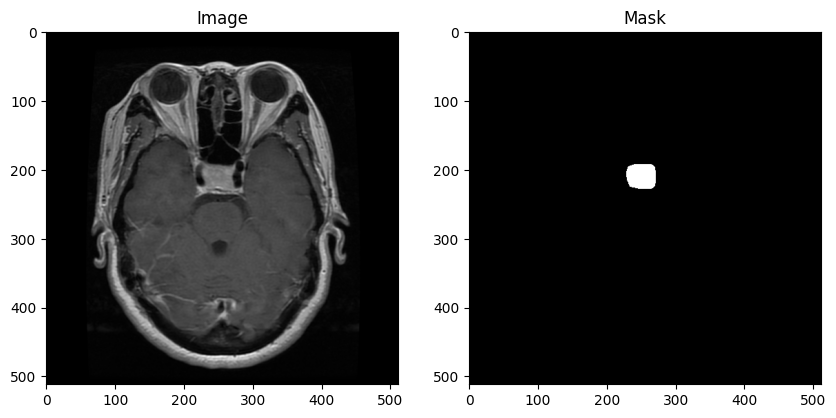

In [ ]:
import matplotlib.pyplot as plt
import cv2

def show_sample(image_files, mask_files, index=0):
    img = cv2.imread(image_files[index])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    mask = cv2.imread(mask_files[index], cv2.IMREAD_GRAYSCALE)
    
    plt.figure(figsize=(10,5))
    
    plt.subplot(1,2,1)
    plt.title("Image")
    plt.imshow(img)
    
    plt.subplot(1,2,2)
    plt.title("Mask")
    plt.imshow(mask, cmap='gray')
    
    plt.show()

show_sample(image_files, mask_files, index=10)

In [43]:
for i in range(5):
    print(os.path.basename(image_files[i]), " | ", os.path.basename(mask_files[i]))

1.png  |  1.png
10.png  |  10.png
100.png  |  100.png
1000.png  |  1000.png
1001.png  |  1001.png


In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model

def build_resunet(input_shape=(256, 256, 3)):
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)

    # Skip connections
    s1 = base_model.input                          
    s2 = base_model.get_layer("conv1_relu").output # 128x128
    s3 = base_model.get_layer("conv2_block3_out").output # 64x64
    s4 = base_model.get_layer("conv3_block4_out").output # 32x32

    # Bridge
    b1 = base_model.get_layer("conv4_block6_out").output # 16x16

    # Decoder
    d1 = UpSampling2D((2,2))(b1)
    d1 = Concatenate()([d1, s4])
    d1 = Conv2D(., 3, padding='same', activation='relu')(d1)
    d1 = Conv2D(256, 3, padding='same', activation='relu')(d1)

    d2 = UpSampling2D((2,2))(d1)
    d2 = Concatenate()([d2, s3])
    d2 = Conv2D(128, 3, padding='same', activation='relu')(d2)
    d2 = Conv2D(128, 3, padding='same', activation='relu')(d2)

    d3 = UpSampling2D((2,2))(d2)
    d3 = Concatenate()([d3, s2])
    d3 = Conv2D(64, 3, padding='same', activation='relu')(d3)
    d3 = Conv2D(64, 3, padding='same', activation='relu')(d3)

    d4 = UpSampling2D((2,2))(d3)
    d4 = Concatenate()([d4, s1])
    d4 = Conv2D(32, 3, padding='same', activation='relu')(d4)
    d4 = Conv2D(32, 3, padding='same', activation='relu')(d4)

    outputs = Conv2D(1, (1,1), activation='sigmoid')(d4)

    return Model(base_model.input, outputs)

In [55]:
import tensorflow.keras.backend as K
import tensorflow as tf

def dice_coef(y_true, y_pred):
    smooth = 1e-6
    
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    
    intersection = K.sum(y_true_f * y_pred_f)
    
    return (2. * intersection + smooth) / (
        K.sum(y_true_f) + K.sum(y_pred_f) + smooth
    )

def dice_loss(y_true, y_pred):
    return 1 - dice_coef(y_true, y_pred)

In [56]:
model = build_resunet()

model.compile(
    optimizer='adam',
    loss=dice_loss,
    metrics=[dice_coef]
)

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 262, 262,  │          0 │ input_layer_2[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 128, 128,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 128, 128,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 128, 128,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 130, 130,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 64, 64,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 64, 64,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 64, 64,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 64, 64,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 64, 64,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 64, 64,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 64, 64,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 64, 64,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 64, 64,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_3_c

 Total params: 13,632,193 (52.00 MB)

 Trainable params: 13,601,601 (51.89 MB)

 Non-trainable params: 30,592 (119.50 KB)

0.0 1.0
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
0.0 0.0


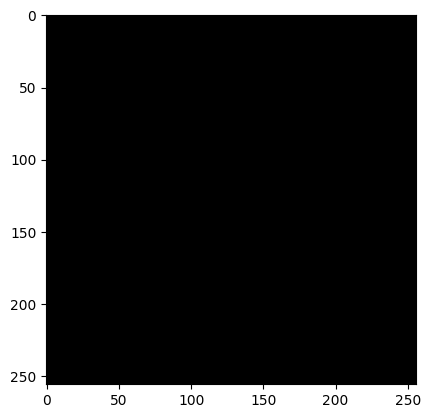

In [59]:
# 1
print(y.min(), y.max())

# 2
pred = model.predict(x)
print(pred.min(), pred.max())

# 3
plt.imshow(pred[0].squeeze(), cmap='gray')

In [60]:
def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.BinaryCrossentropy()(y_true, y_pred)
    dice = 1 - dice_coef(y_true, y_pred)
    return bce + dice

In [62]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=bce_dice_loss,
    metrics=[dice_coef]
)

In [63]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

callbacks = [
    ModelCheckpoint("best_model.h5", save_best_only=True, monitor='val_dice_coef', mode='max'),
    EarlyStopping(patience=10, restore_best_weights=True)
]

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=callbacks
)

Epoch 1/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 0s 423ms/step - dice_coef: 0.0075 - loss: 81.3171

153/153 ━━━━━━━━━━━━━━━━━━━━ 114s 473ms/step - dice_coef: 0.0077 - loss: 80.9372 - val_dice_coef: 0.0025 - val_loss: 1.1169
Epoch 2/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 68s 446ms/step - dice_coef: 0.2266 - loss: 0.8522 - val_dice_coef: 6.8362e-06 - val_loss: 1.2481
Epoch 3/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 0s 422ms/step - dice_coef: 0.4269 - loss: 0.6487

153/153 ━━━━━━━━━━━━━━━━━━━━ 68s 445ms/step - dice_coef: 0.4273 - loss: 0.6483 - val_dice_coef: 0.1475 - val_loss: 0.9778
Epoch 4/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step - dice_coef: 0.6164 - loss: 0.4371

153/153 ━━━━━━━━━━━━━━━━━━━━ 68s 443ms/step - dice_coef: 0.6166 - loss: 0.4369 - val_dice_coef: 0.3527 - val_loss: 0.7400
Epoch 5/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 0s 424ms/step - dice_coef: 0.7039 - loss: 0.3387

153/153 ━━━━━━━━━━━━━━━━━━━━ 69s 448ms/step - dice_coef: 0.7040 - loss: 0.3386 - val_dice_coef: 0.4876 - val_loss: 0.5828
Epoch 6/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 0s 422ms/step - dice_coef: 0.7617 - loss: 0.2731

153/153 ━━━━━━━━━━━━━━━━━━━━ 68s 445ms/step - dice_coef: 0.7617 - loss: 0.2731 - val_dice_coef: 0.6262 - val_loss: 0.4328
Epoch 7/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 0s 424ms/step - dice_coef: 0.7922 - loss: 0.2368

153/153 ━━━━━━━━━━━━━━━━━━━━ 69s 447ms/step - dice_coef: 0.7922 - loss: 0.2367 - val_dice_coef: 0.7163 - val_loss: 0.3352
Epoch 8/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 68s 441ms/step - dice_coef: 0.8346 - loss: 0.1893 - val_dice_coef: 0.7114 - val_loss: 0.3407
Epoch 9/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 0s 423ms/step - dice_coef: 0.8478 - loss: 0.1732

153/153 ━━━━━━━━━━━━━━━━━━━━ 68s 446ms/step - dice_coef: 0.8479 - loss: 0.1731 - val_dice_coef: 0.7496 - val_loss: 0.2925
Epoch 10/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 0s 423ms/step - dice_coef: 0.8671 - loss: 0.1513

153/153 ━━━━━━━━━━━━━━━━━━━━ 68s 447ms/step - dice_coef: 0.8671 - loss: 0.1513 - val_dice_coef: 0.7597 - val_loss: 0.2840


In [64]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5,
    callbacks=callbacks
)

Epoch 1/5
153/153 ━━━━━━━━━━━━━━━━━━━━ 0s 431ms/step - dice_coef: 0.8802 - loss: 0.1357

153/153 ━━━━━━━━━━━━━━━━━━━━ 70s 456ms/step - dice_coef: 0.8802 - loss: 0.1357 - val_dice_coef: 0.7605 - val_loss: 0.2876
Epoch 2/5
153/153 ━━━━━━━━━━━━━━━━━━━━ 0s 422ms/step - dice_coef: 0.8901 - loss: 0.1244

153/153 ━━━━━━━━━━━━━━━━━━━━ 68s 445ms/step - dice_coef: 0.8901 - loss: 0.1244 - val_dice_coef: 0.7620 - val_loss: 0.2823
Epoch 3/5
153/153 ━━━━━━━━━━━━━━━━━━━━ 0s 424ms/step - dice_coef: 0.8944 - loss: 0.1197

153/153 ━━━━━━━━━━━━━━━━━━━━ 68s 447ms/step - dice_coef: 0.8944 - loss: 0.1197 - val_dice_coef: 0.7714 - val_loss: 0.2756
Epoch 4/5
153/153 ━━━━━━━━━━━━━━━━━━━━ 67s 439ms/step - dice_coef: 0.9083 - loss: 0.1039 - val_dice_coef: 0.7637 - val_loss: 0.2860
Epoch 5/5
153/153 ━━━━━━━━━━━━━━━━━━━━ 0s 422ms/step - dice_coef: 0.9053 - loss: 0.1074

153/153 ━━━━━━━━━━━━━━━━━━━━ 68s 446ms/step - dice_coef: 0.9053 - loss: 0.1074 - val_dice_coef: 0.7742 - val_loss: 0.2745


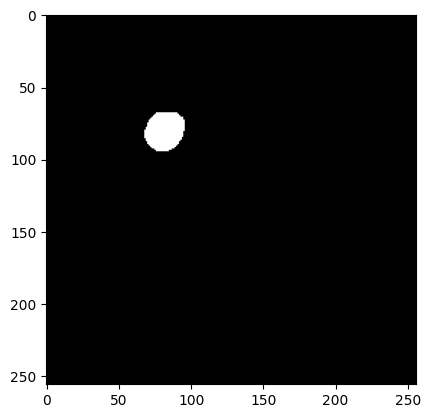

In [53]:
import matplotlib.pyplot as plt
plt.imshow(y[0].squeeze(), cmap='gray')
plt.show()

In [65]:
pred = model.predict(x)
print(pred.min(), pred.max())

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
0.0 1.0


In [ ]:
y = y.astype('float32') / 1.0 

In [ ]:
x, y = train_generator[0] 
print(x.shape, y.shape)

(16, 256, 256, 3) (16, 256, 256, 1)


In [49]:
print(len(train_generator))
print(len(val_generator))

153
19


In [66]:
model.evaluate(test_generator)

19/19 ━━━━━━━━━━━━━━━━━━━━ 7s 374ms/step - dice_coef: 0.7801 - loss: 0.2661


[0.25141963362693787, 0.7914319634437561]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step


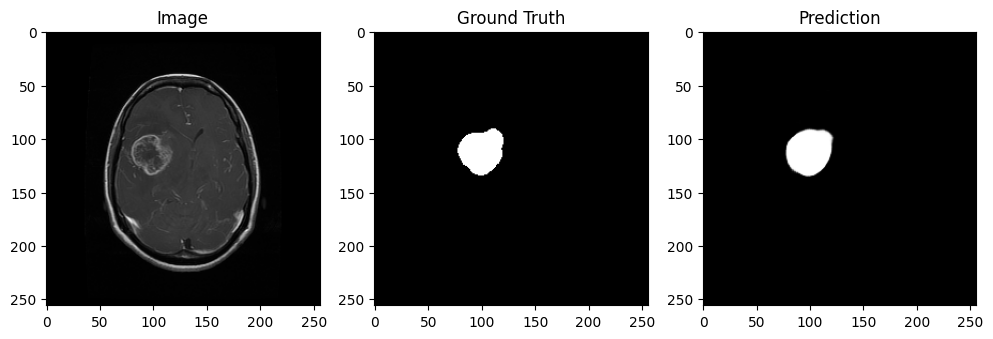

In [ ]:
x, y = test_generator[0]
pred = model.predict(x)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Image")
plt.imshow(x[0])

plt.subplot(1,3,2)
plt.title("Ground Truth")
plt.imshow(y[0].squeeze(), cmap='gray')

plt.subplot(1,3,3)
plt.title("Prediction")
plt.imshow(pred[0].squeeze(), cmap='gray')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step


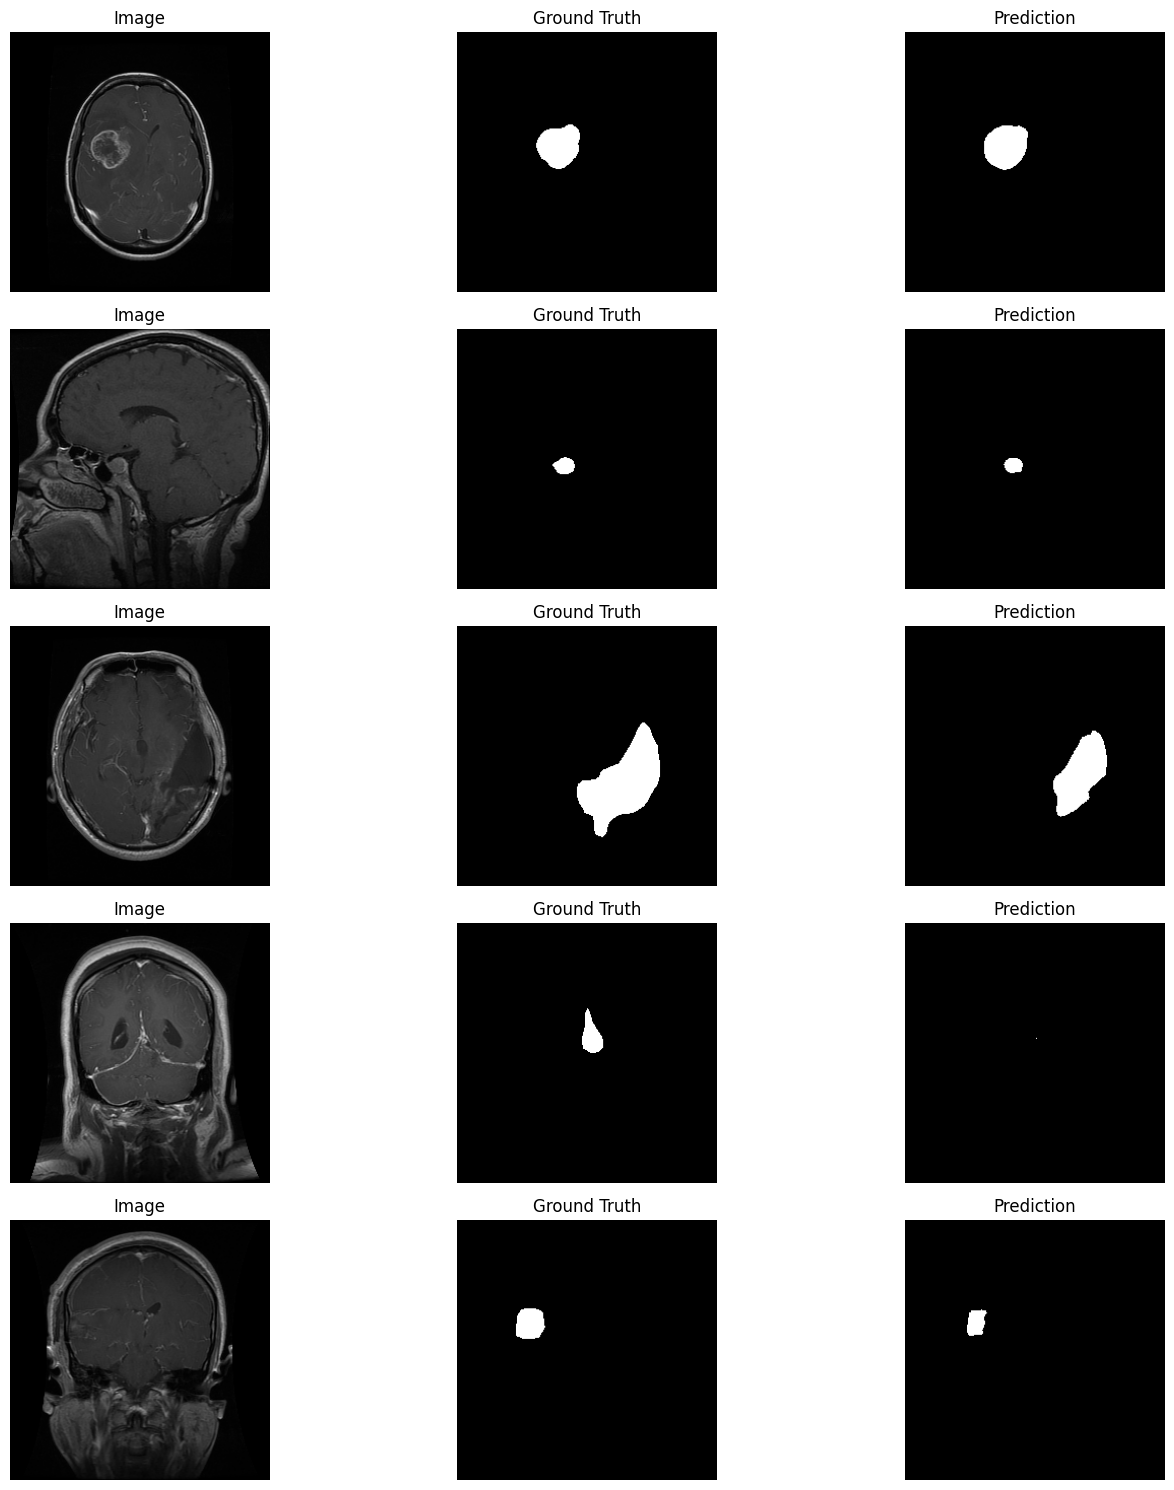

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

x, y = test_generator[0]

pred = model.predict(x)

pred = (pred > 0.5).astype(np.float32)

num_images = 5

plt.figure(figsize=(15, num_images * 3))

for i in range(num_images):
    plt.subplot(num_images, 3, i*3 + 1)
    plt.imshow(x[i])
    plt.title("Image")
    plt.axis("off")

    plt.subplot(num_images, 3, i*3 + 2)
    plt.imshow(y[i].squeeze(), cmap='gray')
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(num_images, 3, i*3 + 3)
    plt.imshow(pred[i].squeeze(), cmap='gray')
    plt.title("Prediction")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [72]:
model.save("my_modelV1.h5")

In [ ]:
model.save("my_model.keras")

In [ ]:
==============================================

Epoch 1/30


2026-04-08 11:42:22.316457: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-08 11:42:22.624151: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-08 11:42:24.151181: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-08 11:42:24.511959: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-08 11:42:25.048095: E external/local_xla/xla/stream_

306/306 ━━━━━━━━━━━━━━━━━━━━ 114s 222ms/step - dice_coef: 0.0942 - loss: 0.9267 - val_dice_coef: 0.0208 - val_loss: 1.0062 - learning_rate: 1.0000e-04
Epoch 2/30
306/306 ━━━━━━━━━━━━━━━━━━━━ 66s 214ms/step - dice_coef: 0.2185 - loss: 0.7934 - val_dice_coef: 0.1955 - val_loss: 0.8433 - learning_rate: 1.0000e-04
Epoch 3/30
306/306 ━━━━━━━━━━━━━━━━━━━━ 65s 212ms/step - dice_coef: 0.3370 - loss: 0.6740 - val_dice_coef: 0.3407 - val_loss: 0.6971 - learning_rate: 1.0000e-04
Epoch 4/30
306/306 ━━━━━━━━━━━━━━━━━━━━ 65s 214ms/step - dice_coef: 0.4662 - loss: 0.5435 - val_dice_coef: 0.5172 - val_loss: 0.4944 - learning_rate: 1.0000e-04
Epoch 5/30
306/306 ━━━━━━━━━━━━━━━━━━━━ 66s 214ms/step - dice_coef: 0.5775 - loss: 0.4320 - val_dice_coef: 0.5456 - val_loss: 0.4700 - learning_rate: 1.0000e-04
Epoch 6/30
306/306 ━━━━━━━━━━━━━━━━━━━━ 65s 213ms/step - dice_coef: 0.6316 - loss: 0.3779 - val_dice_coef: 0.6227 - val_loss: 0.3885 - learning_rate: 1.0000e-04
Epoch 7/30
306/306 ━━━━━━━━━━━━━━━━━━━━ 66s 

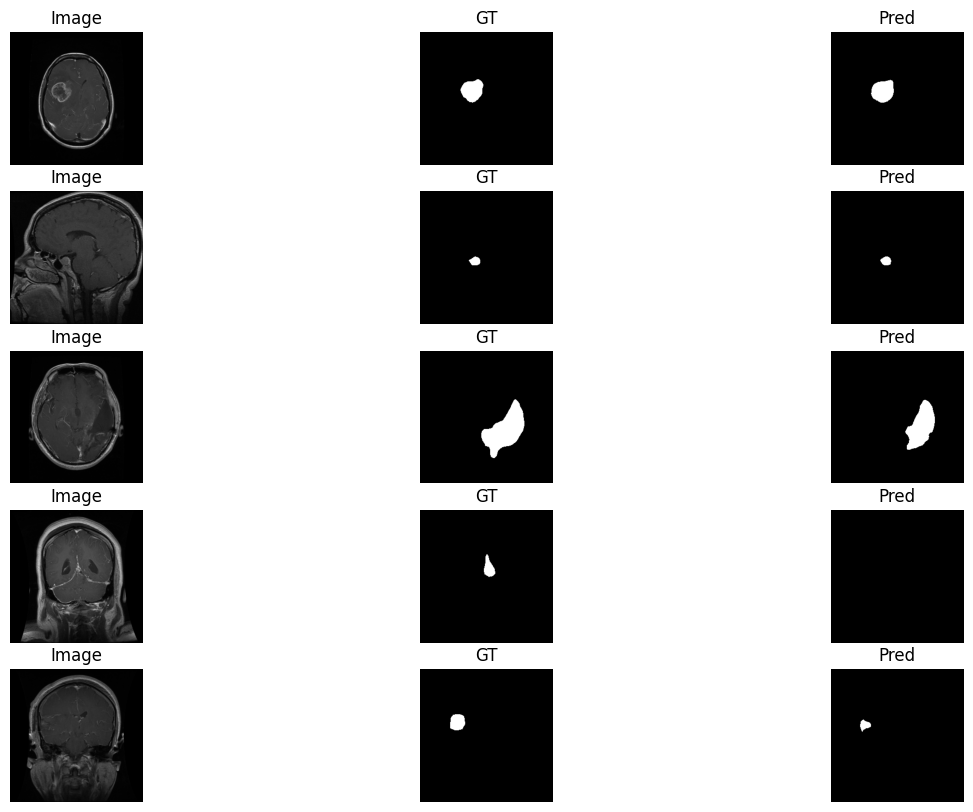

In [ ]:

import cv2

class CustomDataGenerator(tf.keras.utils.Sequence):
    def __init__(self, data_pairs, batch_size, image_size=(256, 256), num_channels=3, shuffle=True, augment=False):
        self.data_pairs = data_pairs
        self.batch_size = batch_size
        self.image_size = image_size
        self.num_channels = num_channels
        self.shuffle = shuffle
        self.augment = augment
        self.on_epoch_end()

    def __len__(self):
        return int(np.floor(len(self.data_pairs) / self.batch_size))

    def __getitem__(self, index):
        indexes = self.indexes[index*self.batch_size:(index+1)*self.batch_size]
        batch_pairs = [self.data_pairs[k] for k in indexes]
        X, y = self.__data_generation(batch_pairs)
        return X, y

    def on_epoch_end(self):
        self.indexes = np.arange(len(self.data_pairs))
        if self.shuffle:
            np.random.shuffle(self.indexes)

    def __data_generation(self, batch_pairs):
        X = np.empty((self.batch_size, *self.image_size, self.num_channels), dtype=np.float32)
        y = np.empty((self.batch_size, *self.image_size, 1), dtype=np.float32)

        for i, (img_path, mask_path) in enumerate(batch_pairs):

            # Image
            img = cv2.imread(img_path)
            img = cv2.resize(img, self.image_size)
            img = img / 255.0

            # Mask
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            mask = cv2.resize(mask, self.image_size)
            mask = mask / 255.0
            mask = np.expand_dims(mask, axis=-1)

            if self.augment:
                if np.random.rand() > 0.5:
                    img = np.fliplr(img)
                    mask = np.fliplr(mask)

                if np.random.rand() > 0.5:
                    img = np.flipud(img)
                    mask = np.flipud(mask)

            mask = (mask > 0.5).astype(np.float32)

            X[i] = img
            y[i] = mask

        return X, y


train_generator = CustomDataGenerator(train, batch_size=8, augment=True)
val_generator   = CustomDataGenerator(val, batch_size=8, augment=False)
test_generator  = CustomDataGenerator(test, batch_size=8, shuffle=False)



from tensorflow.keras import layers, Model

def conv_block(x, filters):
    x = layers.Conv2D(filters, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.Conv2D(filters, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    return x

def build_unet(input_shape=(256,256,3)):
    inputs = layers.Input(input_shape)

    # Encoder
    c1 = conv_block(inputs, 32)
    p1 = layers.MaxPooling2D()(c1)

    c2 = conv_block(p1, 64)
    p2 = layers.MaxPooling2D()(c2)

    c3 = conv_block(p2, 128)
    p3 = layers.MaxPooling2D()(c3)

    c4 = conv_block(p3, 256)
    p4 = layers.MaxPooling2D()(c4)

    # Bridge
    b = conv_block(p4, 512)

    # Decoder
    u1 = layers.UpSampling2D()(b)
    u1 = layers.concatenate([u1, c4])
    c5 = conv_block(u1, 256)

    u2 = layers.UpSampling2D()(c5)
    u2 = layers.concatenate([u2, c3])
    c6 = conv_block(u2, 128)

    u3 = layers.UpSampling2D()(c6)
    u3 = layers.concatenate([u3, c2])
    c7 = conv_block(u3, 64)

    u4 = layers.UpSampling2D()(c7)
    u4 = layers.concatenate([u4, c1])
    c8 = conv_block(u4, 32)

    outputs = layers.Conv2D(1, 1, activation="sigmoid")(c8)

    return Model(inputs, outputs)

model = build_unet()



def dice_coef(y_true, y_pred, smooth=1):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)

    intersection = tf.reduce_sum(y_true_f * y_pred_f)

    return (2. * intersection + smooth) / (
        tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth
    )

def focal_loss(y_true, y_pred, gamma=2, alpha=0.25):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    bce_exp = tf.exp(-bce)
    return alpha * (1 - bce_exp) ** gamma * bce

def total_loss(y_true, y_pred):
    return focal_loss(y_true, y_pred) + (1 - dice_coef(y_true, y_pred))



model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=total_loss,
    metrics=[dice_coef]
)



from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6
)



history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=30,
    callbacks=[early_stop, reduce_lr]
)



x, y = test_generator[0]
pred = model.predict(x)
pred = (pred > 0.5).astype(np.float32)

import matplotlib.pyplot as plt

plt.figure(figsize=(15,10))

for i in range(5):
    plt.subplot(5,3,i*3+1)
    plt.imshow(x[i])
    plt.title("Image")
    plt.axis('off')

    plt.subplot(5,3,i*3+2)
    plt.imshow(y[i].squeeze(), cmap='gray')
    plt.title("GT")
    plt.axis('off')

    plt.subplot(5,3,i*3+3)
    plt.imshow(pred[i].squeeze(), cmap='gray')
    plt.title("Pred")
    plt.axis('off')

plt.show()


In [106]:
model.evaluate(test_generator)

38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - dice_coef: 0.8119 - loss: 0.1973


[0.1798824667930603, 0.8282791376113892]

In [107]:
model.save('my_modelV2.keras')